# 03 · Resultados: modelos, walk-forward y significancia

> **Experimento educativo. El Baloto es aleatorio; este modelo no predice resultados. Juega con responsabilidad.**

Este notebook reúne el resultado central del proyecto: dos modelos razonables, entrenados solo con el pasado y evaluados como se usarían en producción, **no superan al azar**. Y, para que ese "no" valga algo, verifica que el método sí detecta una señal cuando existe.

Cifras de `reports/evaluation/*.json` (etapa `evaluate`) y `reports/significance/*.json` (etapa `significance`, lenta).

In [1]:
from dataclasses import replace
from functools import partial

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

from baloto_ml import viz
from baloto_ml.config import EXPECTED_HITS, JUEGOS, N_SIMS, P_BALL, default_paths
from baloto_ml.data.store import read_draws, read_json
from baloto_ml.evaluation.metrics import LOG_LOSS_BALL_CONST, evaluate_probabilities, reliability_curve
from baloto_ml.evaluation.significance import outcome_null
from baloto_ml.evaluation.stats import rng_for
from baloto_ml.evaluation.walk_forward import walk_forward
from baloto_ml.models.base import GameData
from baloto_ml.models.catalog import MODELS
from baloto_ml.models.classifiers import PerNumberLogistic

viz.apply_style()
pd.set_option("display.precision", 4)
paths = default_paths()
FIG = paths.figures
data = {j: GameData.from_draws(read_draws(paths.processed_draws), j) for j in JUEGOS}
ev = {j: read_json(paths.evaluation_report(j)) for j in JUEGOS}
sig = {j: read_json(paths.significance_report(j)) for j in JUEGOS}
controles = read_json(paths.controls_report)
NOMBRES = {"constante": "constante", "frecuencia": "frecuencia", "logistica": "logística", "gradient_boosting": "gradient boosting"}


def ic(par, nd=3):
    return f"[{par[0]:.{nd}f}, {par[1]:.{nd}f}]"

## 1. Qué se evaluó

**Features** (solo sorteos anteriores al objetivo; ver `baloto_ml/features/build.py`): para cada número, su frecuencia en los últimos 10, 30 y 100 sorteos, los sorteos transcurridos desde su última aparición y una tendencia (frecuencia de los últimos 15 menos la de los 15 anteriores); además, el día de la semana del sorteo.

**Modelos**, con hiperparámetros fijados antes de ver resultados:

| modelo | qué es | por qué |
|---|---|---|
| constante | 5/43 y 1/16 | el modelo correcto si el sorteo es justo |
| frecuencia | frecuencia histórica acumulada | la intuición "sale más lo que más ha salido" |
| logística | una regresión logística por balota (43) y por superbalota (16), L2 con C = 1 | puede capturar un sesgo propio de cada número |
| gradient boosting | un `HistGradientBoosting` compartido por los 43 números (formato largo), sin early stopping | busca dinámicas comunes (rachas, "calientes/fríos") con 43 veces más filas |

**Validación walk-forward**: los primeros 100 sorteos son solo historia; se entrena con los 150 siguientes y se predice cada sorteo usando solo el pasado, reentrenando cada 10. El modelo de producción (el que alimenta el registro en vivo) es la **logística**, fijada a priori y no elegida por métricas.

## 2. Resultados walk-forward (384 sorteos de prueba por juego)

In [2]:
filas = []
for j in JUEGOS:
    for nombre, m in ev[j]["modelos"].items():
        b, s = m["balotas"], m["superbalota"]
        filas.append(
            {
                "juego": j,
                "modelo": NOMBRES[nombre],
                "aciertos top-5": b["aciertos_top5_media"],
                "IC95 aciertos": ic(b["aciertos_top5_ic95"]),
                "log-loss por balota": b["log_loss"],
                "skill vs constante": b["skill_log_loss"],
                "IC95 Δ log-loss": ic(b["delta_log_loss_ic95"], 4),
                "accuracy superbalota": s["accuracy"],
                "skill superbalota": s["skill_log_loss"],
            }
        )
pd.DataFrame(filas).set_index(["juego", "modelo"])

aciertos top-5   IC95 aciertos  \
juego    modelo                                              
baloto   constante                  0.6224  [0.551, 0.694]   
         frecuencia                 0.5286  [0.462, 0.595]   
         logística                  0.5339  [0.465, 0.603]   
         gradient boosting          0.5599  [0.490, 0.629]   
revancha constante                  0.5990  [0.526, 0.672]   
         frecuencia                 0.5495  [0.483, 0.616]   
         logística                  0.5677  [0.502, 0.633]   
         gradient boosting          0.5339  [0.470, 0.598]   

                            log-loss por balota  skill vs constante  \
juego    modelo                                                       
baloto   constante                       0.3594              0.0000   
         frecuencia                      0.3608             -0.0038   
         logística                       0.3767             -0.0479   
         gradient boosting               0.3608             -0.0039   
revancha constante                       0.3594              0.0000   
         frecuencia                      0.3606             -0.0032   
         logística                       0.3778             -0.0510   
         gradient boosting               0.3612             -0.0048   

                             IC95 Δ log-loss  accuracy superbalota  \
juego    modelo                                                      
baloto   constante          [0.0000, 0.0000]                0.0495   
         frecuencia         [0.0007, 0.0020]                0.0573   
         logística          [0.0144, 0.0200]                0.0781   
         gradient boosting  [0.0006, 0.0022]                0.0599   
revancha constante          [0.0000, 0.0000]                0.0677   
         frecuencia         [0.0004, 0.0018]                0.0625   
         logística          [0.0151, 0.0216]                0.0547   
         gradient boosting  [0.0010, 0.0025]                0.0729   

                            skill superbalota  
juego    modelo                                
baloto   constante                     0.0000  
         frecuencia                   -0.0071  
         logística                    -0.0616  
         gradient boosting            -0.0215  
revancha constante                     0.0000  
         frecuencia                   -0.0034  
         logística                    -0.0691  
         gradient boosting            -0.0098

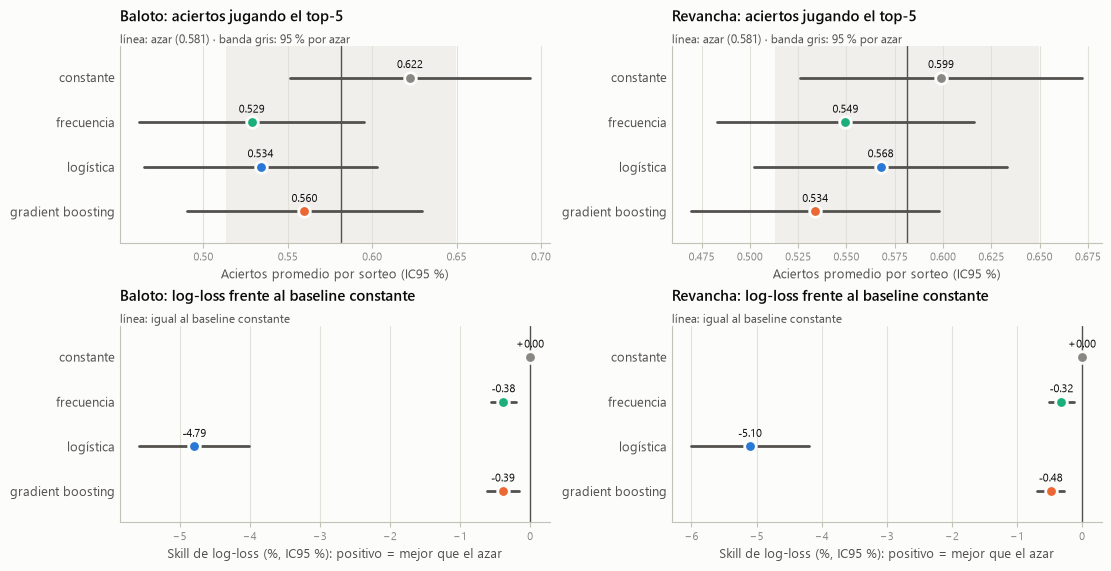

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(11, 5.6), layout="constrained")
for col, j in enumerate(JUEGOS):
    mods = ev[j]["modelos"]
    etiquetas = [NOMBRES[n] for n in mods]
    colores = [viz.MODEL_COLORS[n] for n in mods]
    viz.interval_dots(
        axes[0, col], etiquetas,
        [m["balotas"]["aciertos_top5_media"] for m in mods.values()],
        [m["balotas"]["aciertos_top5_ic95"] for m in mods.values()],
        EXPECTED_HITS, ev[j]["referencias_azar"]["aciertos_top5_banda95"],
        f"{j.capitalize()}: aciertos jugando el top-5", "Aciertos promedio por sorteo (IC95 %)", colors=colores,
    )
    skills = [m["balotas"]["skill_log_loss"] for m in mods.values()]
    ics = [[-m["balotas"]["delta_log_loss_ic95"][1] / LOG_LOSS_BALL_CONST, -m["balotas"]["delta_log_loss_ic95"][0] / LOG_LOSS_BALL_CONST] for m in mods.values()]
    viz.interval_dots(
        axes[1, col], etiquetas, [100 * s for s in skills], [[100 * lo, 100 * hi] for lo, hi in ics],
        0.0, None, f"{j.capitalize()}: log-loss frente al baseline constante",
        "Skill de log-loss (%, IC95 %): positivo = mejor que el azar", colors=colores,
        note="línea: igual al baseline constante", fmt="{:+.2f}",
    )
viz.save(fig, FIG / "modelos_walk_forward.png")
plt.show()

In [4]:
lg = {j: ev[j]["modelos"]["logistica"]["balotas"] for j in JUEGOS}
gb = {j: ev[j]["modelos"]["gradient_boosting"]["balotas"] for j in JUEGOS}
display(Markdown(f"""**Lectura.** Ningún modelo supera al azar en aciertos: todos caen dentro de la banda de lo esperable. En log-loss **todos son peores que el baseline constante**, con intervalos enteramente del lado negativo: el gradient boosting por poco ({100 * gb['baloto']['skill_log_loss']:+.2f} % en Baloto, {100 * gb['revancha']['skill_log_loss']:+.2f} % en Revancha) y la logística por mucho ({100 * lg['baloto']['skill_log_loss']:+.2f} % y {100 * lg['revancha']['skill_log_loss']:+.2f} %). Si el sorteo es justo, eso es lo esperado: cualquier desviación del 5/43 es ruido, y el ruido se paga en log-loss."""))

**Lectura.** Ningún modelo supera al azar en aciertos: todos caen dentro de la banda de lo esperable. En log-loss **todos son peores que el baseline constante**, con intervalos enteramente del lado negativo: el gradient boosting por poco (-0.39 % en Baloto, -0.48 % en Revancha) y la logística por mucho (-4.79 % y -5.10 %). Si el sorteo es justo, eso es lo esperado: cualquier desviación del 5/43 es ruido, y el ruido se paga en log-loss.

## 3. ¿Se distinguen del azar? Monte Carlo sobre los resultados

Se fijan las predicciones walk-forward de cada modelo y se simulan 10 000 secuencias de sorteos justos del mismo largo. Como cada predicción usa solo el pasado, bajo un sorteo justo el resultado es independiente de ella: esta es la distribución exacta de las métricas del modelo **si no hubiera nada que aprender**. El p-valor mide la probabilidad de obtener, por azar, un resultado igual o mejor que el observado.

In [5]:
filas = []
for j in JUEGOS:
    for nombre, m in ev[j]["modelos"].items():
        if nombre == "constante":
            continue
        mc = m["significancia_monte_carlo"]
        filas.append(
            {
                "juego": j,
                "modelo": NOMBRES[nombre],
                "p aciertos top-5": mc["aciertos_top5"]["p_valor"],
                "p log-loss balotas": mc["log_loss_balotas"]["p_valor"],
                "p accuracy superbalota": mc["accuracy_superbalota"]["p_valor"],
                "p log-loss superbalota": mc["log_loss_superbalota"]["p_valor"],
            }
        )
pd.DataFrame(filas).set_index(["juego", "modelo"])

p aciertos top-5  p log-loss balotas  \
juego    modelo                                                    
baloto   frecuencia                   0.9436              0.9176   
         logística                    0.9201              0.7938   
         gradient boosting            0.7397              0.5319   
revancha frecuencia                   0.8277              0.6951   
         logística                    0.6605              0.8163   
         gradient boosting            0.9189              0.9275   

                            p accuracy superbalota  p log-loss superbalota  
juego    modelo                                                             
baloto   frecuencia                         0.6899                  0.7882  
         logística                          0.1232                  0.2326  
         gradient boosting                  0.6134                  0.9422  
revancha frecuencia                         0.5285                  0.2531  
         logística                          0.7630                  0.1340  
         gradient boosting                  0.2230                  0.3646

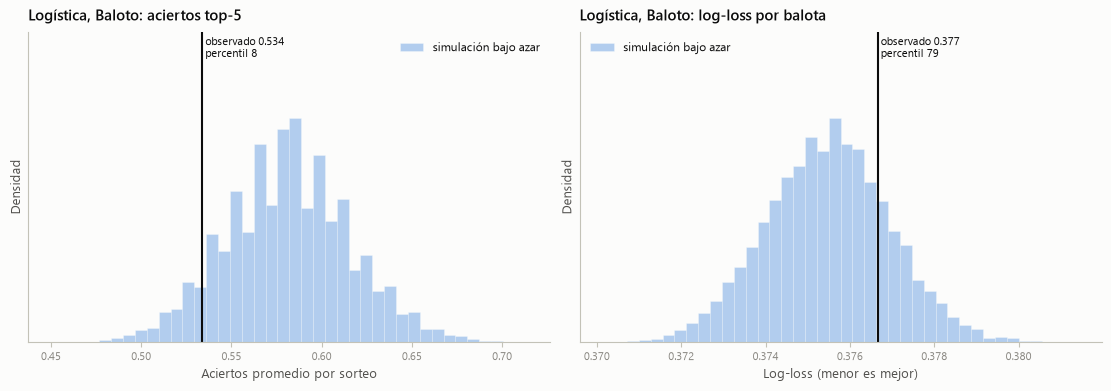

In [6]:
wf_lg = {j: walk_forward(MODELS["logistica"], data[j]) for j in JUEGOS}
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), layout="constrained")
j = "baloto"
null = outcome_null(wf_lg[j].probs, N_SIMS, rng_for("mc-resultados", j, "logistica"))
viz.null_panel(axes[0], null["aciertos_top5"], lg[j]["aciertos_top5_media"], "Logística, Baloto: aciertos top-5", "Aciertos promedio por sorteo", bins=40)
viz.null_panel(axes[1], null["log_loss_balotas"], lg[j]["log_loss"], "Logística, Baloto: log-loss por balota", "Log-loss (menor es mejor)", bins=40)
viz.save(fig, FIG / "mc_resultados_logistica.png")
plt.show()

## 4. Las combinaciones ganadoras, vistas por el modelo

Si la logística supiera algo, las combinaciones que de verdad ganaron deberían tener, **antes del sorteo**, un puntaje más alto que una jugada al azar. Para cada sorteo de prueba se calcula en qué percentil quedó la combinación ganadora entre 2000 jugadas aleatorias, según el puntaje del modelo en ese momento. Sin señal, esos percentiles se reparten de forma pareja entre 0 y 100.

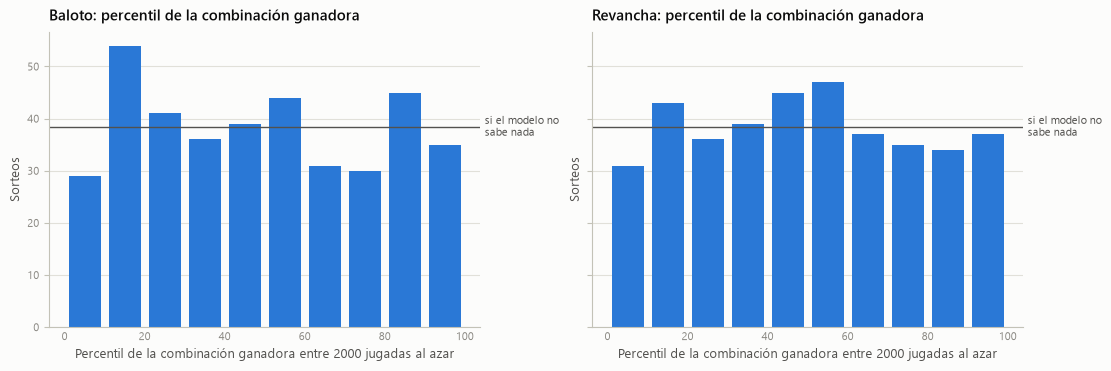

Percentil medio: 0.491 en Baloto (IC95 % [0.462, 0.520]) y 0.501 en Revancha ([0.473, 0.529]), frente a 0.5 esperado por azar; la prueba de Kolmogorov-Smirnov contra una distribución uniforme da p = 0.62 y 0.87. **El puntaje del modelo no tiene relación con lo que después sale.**

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), sharey=True, layout="constrained")
for ax, j in zip(axes, JUEGOS):
    pg = ev[j]["modelos"]["logistica"]["percentil_ganadoras"]
    viz.percentile_hist(ax, np.array(pg["percentiles"]), f"{j.capitalize()}: percentil de la combinación ganadora")
viz.save(fig, FIG / "percentil_ganadoras.png")
plt.show()
pgb, pgr = (ev[j]["modelos"]["logistica"]["percentil_ganadoras"] for j in JUEGOS)
display(Markdown(f"""Percentil medio: {pgb['media']:.3f} en Baloto (IC95 % {ic(pgb['media_ic95'])}) y {pgr['media']:.3f} en Revancha ({ic(pgr['media_ic95'])}), frente a 0.5 esperado por azar; la prueba de Kolmogorov-Smirnov contra una distribución uniforme da p = {pgb['p_valor_ks_uniforme']:.2f} y {pgr['p_valor_ks_uniforme']:.2f}. **El puntaje del modelo no tiene relación con lo que después sale.**"""))

## 5. Permutación e historiales sintéticos, con reentrenamiento

Las pruebas anteriores dejan fijas las predicciones. Estas repiten **todo** el walk-forward, reentrenando:

- **Permutación**: se baraja el orden de los sorteos reales (conserva las frecuencias de cada número, destruye solo el orden temporal).
- **Historiales sintéticos**: sorteos uniformes del mismo tamaño (lo que produce el pipeline completo cuando no hay nada que aprender).

Si el orden real tuviera información, el resultado observado quedaría en la cola derecha de estas distribuciones.

In [8]:
filas = []
for j in JUEGOS:
    for nombre, res in sig[j]["modelos"].items():
        for tipo in ("permutacion", "sintetico"):
            for metrica in ("skill_log_loss_balotas", "aciertos_top5"):
                s = res[tipo]["metricas"][metrica]
                filas.append({"juego": j, "modelo": NOMBRES[nombre], "prueba": f"{tipo} (n={res[tipo]['n']})", "métrica": metrica, "observado": s["observado"], "media nula": s["nulo_media"], "percentil": s["percentil"], "p": s["p_valor"]})
pd.DataFrame(filas).set_index(["juego", "modelo", "prueba", "métrica"])

observado  \
juego    modelo            prueba              métrica                             
baloto   logística         permutacion (n=200) skill_log_loss_balotas    -0.0479   
                                               aciertos_top5              0.5339   
                           sintetico (n=1000)  skill_log_loss_balotas    -0.0479   
                                               aciertos_top5              0.5339   
         gradient boosting permutacion (n=200) skill_log_loss_balotas    -0.0039   
                                               aciertos_top5              0.5599   
                           sintetico (n=200)   skill_log_loss_balotas    -0.0039   
                                               aciertos_top5              0.5599   
revancha logística         permutacion (n=200) skill_log_loss_balotas    -0.0510   
                                               aciertos_top5              0.5677   
                           sintetico (n=1000)  skill_log_loss_balotas    -0.0510   
                                               aciertos_top5              0.5677   
         gradient boosting permutacion (n=200) skill_log_loss_balotas    -0.0048   
                                               aciertos_top5              0.5365   
                           sintetico (n=200)   skill_log_loss_balotas    -0.0048   
                                               aciertos_top5              0.5365   

                                                                       media nula  \
juego    modelo            prueba              métrica                              
baloto   logística         permutacion (n=200) skill_log_loss_balotas     -0.0507   
                                               aciertos_top5               0.5723   
                           sintetico (n=1000)  skill_log_loss_balotas     -0.0498   
                                               aciertos_top5               0.5819   
         gradient boosting permutacion (n=200) skill_log_loss_balotas     -0.0034   
                                               aciertos_top5               0.5740   
                           sintetico (n=200)   skill_log_loss_balotas     -0.0034   
                                               aciertos_top5               0.5827   
revancha logística         permutacion (n=200) skill_log_loss_balotas     -0.0509   
                                               aciertos_top5               0.5741   
                           sintetico (n=1000)  skill_log_loss_balotas     -0.0500   
                                               aciertos_top5               0.5805   
         gradient boosting permutacion (n=200) skill_log_loss_balotas     -0.0034   
                                               aciertos_top5               0.5783   
                           sintetico (n=200)   skill_log_loss_balotas     -0.0035   
                                               aciertos_top5               0.5790   

                                                                       percentil  \
juego    modelo            prueba              métrica                             
baloto   logística         permutacion (n=200) skill_log_loss_balotas       76.5   
                                               aciertos_top5                13.5   
                           sintetico (n=1000)  skill_log_loss_balotas       67.5   
                                               aciertos_top5                 9.9   
         gradient boosting permutacion (n=200) skill_log_loss_balotas       33.0   
                                               aciertos_top5                34.0   
                           sintetico (n=200)   skill_log_loss_balotas       29.5   
                                               aciertos_top5                25.0   
revancha logística         permutacion (n=200) skill_log_loss_balotas       45.5   
                                               aciertos_top5                42.5   
                   

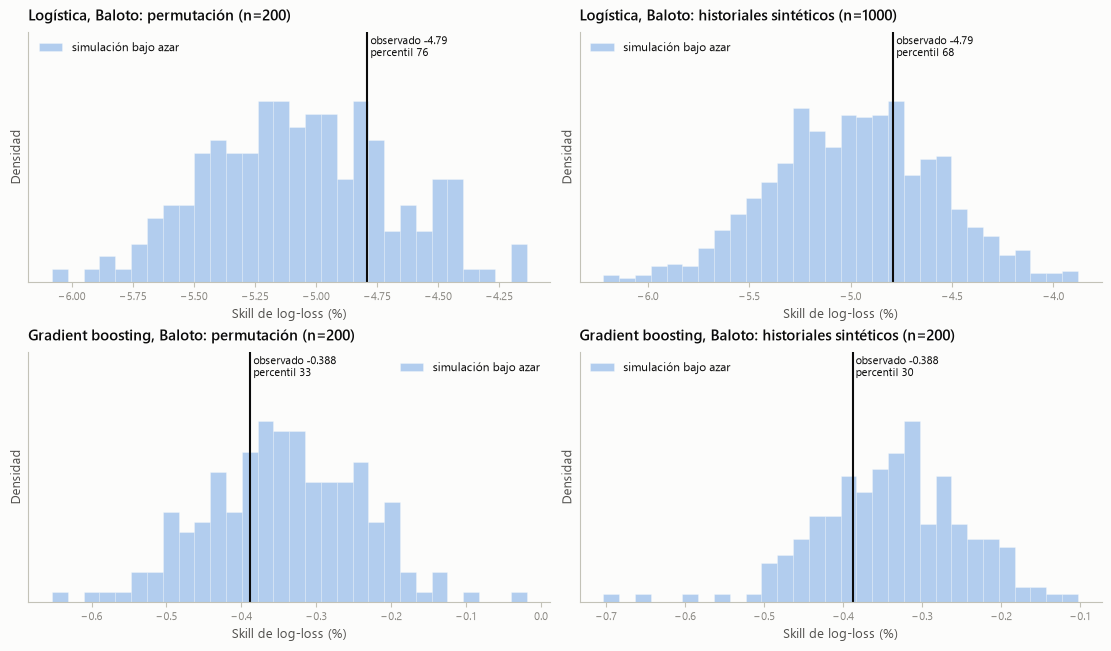

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(11, 6.4), layout="constrained")
for row, nombre in enumerate(("logistica", "gradient_boosting")):
    for col, tipo in enumerate(("permutacion", "sintetico")):
        res = sig["baloto"]["modelos"][nombre][tipo]
        s = res["metricas"]["skill_log_loss_balotas"]
        viz.null_panel(
            axes[row, col], 100 * np.array(s["muestras"]), 100 * s["observado"],
            f"{NOMBRES[nombre].capitalize()}, Baloto: {'permutación' if tipo == 'permutacion' else 'historiales sintéticos'} (n={res['n']})",
            "Skill de log-loss (%)", bins=30,
        )
viz.save(fig, FIG / "remuestreo_baloto.png")
plt.show()

## 6. ¿El método es capaz de ver señal? Control positivo

Un resultado negativo solo vale si el método habría detectado una señal real. Se generan historiales sintéticos con una señal **plantada**: los números que salieron en el sorteo anterior pesan 1,5 o 2,5 veces más en el siguiente (efecto 0,5 y 1,5; efecto 0 = sorteo justo). Luego se corre exactamente el mismo walk-forward.

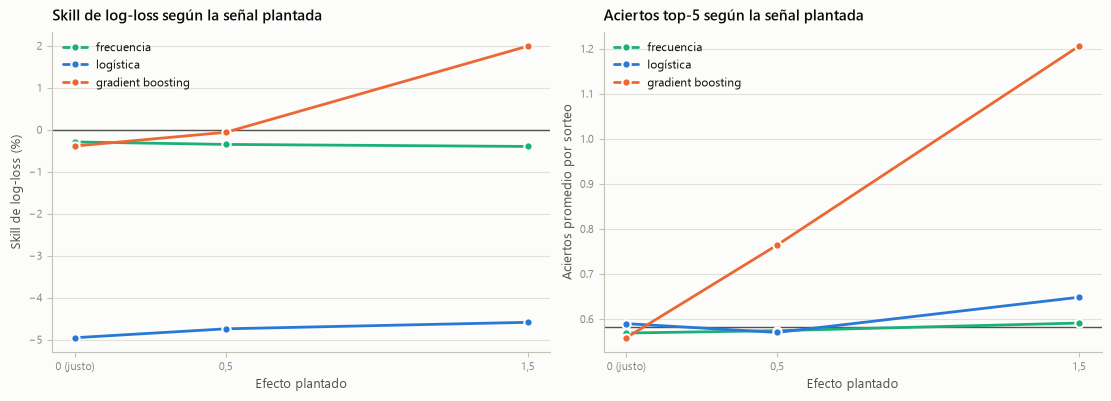

aciertos_top5                 skill_log_loss_balotas  \
efecto                      0.0     0.5     1.5                    0.0   
modelo                                                                   
frecuencia               0.5690  0.5742  0.5911                -0.0029   
gradient boosting        0.5586  0.7643  1.2057                -0.0039   
logística                0.5898  0.5703  0.6484                -0.0495   

                                   
efecto                0.5     1.5  
modelo                             
frecuencia        -0.0035 -0.0040  
gradient boosting -0.0006  0.0199  
logística         -0.0474 -0.0459

In [10]:
pc = pd.DataFrame(controles["control_positivo"])
efectos = sorted(pc["efecto"].unique())
fig, axes = plt.subplots(1, 2, figsize=(11, 3.9), layout="constrained")
series_skill = {NOMBRES[m]: [100 * pc[(pc.modelo == m) & (pc.efecto == e)]["skill_log_loss_balotas"].iloc[0] for e in efectos] for m in pc.modelo.unique()}
series_hits = {NOMBRES[m]: [pc[(pc.modelo == m) & (pc.efecto == e)]["aciertos_top5"].iloc[0] for e in efectos] for m in pc.modelo.unique()}
colores = {NOMBRES[m]: viz.MODEL_COLORS[m] for m in pc.modelo.unique()}
etiquetas = ["0 (justo)", "0,5", "1,5"]
viz.line_panel(axes[0], efectos, series_skill, colores, "Skill de log-loss según la señal plantada", "Efecto plantado", "Skill de log-loss (%)", reference=0.0, xticklabels=etiquetas)
viz.line_panel(axes[1], efectos, series_hits, colores, "Aciertos top-5 según la señal plantada", "Efecto plantado", "Aciertos promedio por sorteo", reference=EXPECTED_HITS, xticklabels=etiquetas)
viz.save(fig, FIG / "control_positivo.png")
plt.show()
pc.assign(modelo=pc.modelo.map(NOMBRES)).pivot(index="modelo", columns="efecto", values=["aciertos_top5", "skill_log_loss_balotas"])

In [11]:
g15 = pc[(pc.modelo == "gradient_boosting") & (pc.efecto == 1.5)].iloc[0]
l15 = pc[(pc.modelo == "logistica") & (pc.efecto == 1.5)].iloc[0]
display(Markdown(f"""**Lectura.** El **gradient boosting** detecta la señal plantada fuerte en aciertos ({g15['aciertos_top5']:.3f}) y en log-loss ({100 * g15['skill_log_loss_balotas']:+.2f} %): es un detector válido, así que su resultado negativo con los datos reales es informativo. La **logística** por balota reacciona en aciertos ({l15['aciertos_top5']:.3f}) pero **nunca** supera al baseline en log-loss, ni siquiera con señal fuerte ({100 * l15['skill_log_loss_balotas']:+.2f} %): con unos 50 aciertos por balota para aprender 8 coeficientes, la varianza tapa la señal. Es un instrumento pobre para medir probabilidades, y así se reporta."""))

**Lectura.** El **gradient boosting** detecta la señal plantada fuerte en aciertos (1.206) y en log-loss (+1.99 %): es un detector válido, así que su resultado negativo con los datos reales es informativo. La **logística** por balota reacciona en aciertos (0.648) pero **nunca** supera al baseline en log-loss, ni siquiera con señal fuerte (-4.59 %): con unos 50 aciertos por balota para aprender 8 coeficientes, la varianza tapa la señal. Es un instrumento pobre para medir probabilidades, y así se reporta.

## 7. Dos decisiones, contadas con honestidad

**La primera versión de la logística tenía un defecto.** Estandarizaba todas las features, incluida la variable "lunes", que al principio casi siempre vale 0 (los lunes existen desde junio de 2025): con 2 o 3 lunes en el entrenamiento, un lunes quedaba a ~10 desviaciones estándar y la regularización dejaba de frenarla. Además, la sequía (sorteos desde la última aparición) tiene cola larga y la logística extrapolaba sin freno. Resultado: probabilidades de hasta 0,99 para una balota. Se corrigió con dos prácticas estándar (indicadores sin escalar y `log1p` en la sequía) sin tocar C ni ningún otro hiperparámetro. La versión inicial se conserva (`PerNumberLogistic(legacy_preprocessing=True)`):

In [12]:
filas = []
for j in JUEGOS:
    for etiqueta, fabrica in (("v1: inicial (defectuosa)", partial(PerNumberLogistic, legacy_preprocessing=True)), ("v2: corregida (la que se usa)", PerNumberLogistic)):
        wf = wf_lg[j] if etiqueta.startswith("v2") else walk_forward(fabrica, data[j])
        m = evaluate_probabilities(wf.probs, data[j].y_balls[wf.test_idx], data[j].y_sb[wf.test_idx], rng_for("desempate", j, "logistica"))
        filas.append({"juego": j, "versión": etiqueta, "máxima probabilidad de una balota": wf.probs.balls.max(), "aciertos top-5": m["balotas"]["aciertos_top5_media"], "skill log-loss": m["balotas"]["skill_log_loss"]})
pd.DataFrame(filas).set_index(["juego", "versión"])

máxima probabilidad de una balota  \
juego    versión                                                            
baloto   v1: inicial (defectuosa)                                  0.9861   
         v2: corregida (la que se usa)                             0.6646   
revancha v1: inicial (defectuosa)                                  0.9910   
         v2: corregida (la que se usa)                             0.6703   

                                        aciertos top-5  skill log-loss  
juego    versión                                                        
baloto   v1: inicial (defectuosa)               0.5495         -0.0745  
         v2: corregida (la que se usa)          0.5339         -0.0479  
revancha v1: inicial (defectuosa)               0.5443         -0.0842  
         v2: corregida (la que se usa)          0.5677         -0.0510

**C no se "optimizó".** Tras el control positivo se exploró cómo cambia la logística con distintos valores de C, **solo en historiales sintéticos**. Ningún valor la hace superar al baseline en log-loss, ni con señal plantada: regularizar más la acerca al constante (y la vuelve ciega a la señal), regularizar menos la hace más ruidosa. C se quedó en su valor a priori; elegirlo mirando resultados sería otra forma de buscar hasta encontrar.

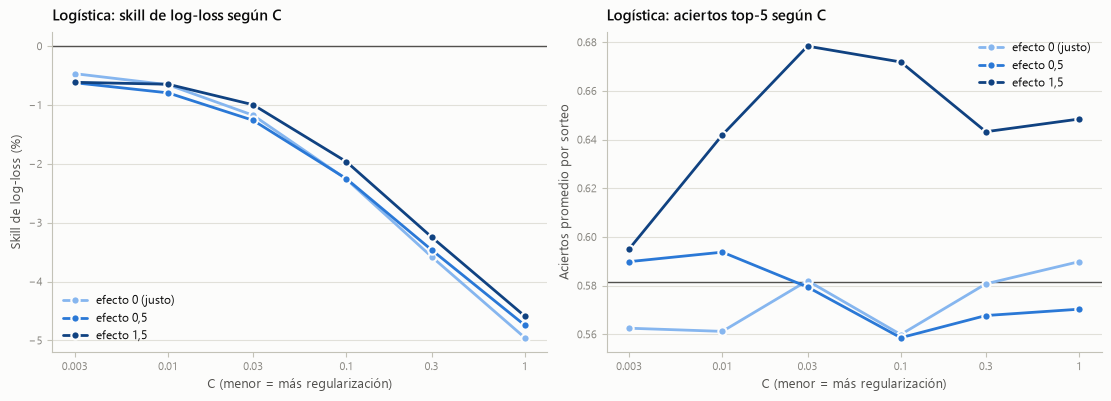

In [13]:
rg = pd.DataFrame(controles["regularizacion_logistica"])
cs = sorted(rg["C"].unique())
fig, axes = plt.subplots(1, 2, figsize=(11, 3.9), layout="constrained")
nombres_ef = {0.0: "efecto 0 (justo)", 0.5: "efecto 0,5", 1.5: "efecto 1,5"}
colores = dict(zip(nombres_ef.values(), viz.ORDINAL_BLUES))
s_skill = {nombres_ef[e]: [100 * rg[(rg.C == c) & (rg.efecto == e)]["skill_log_loss_balotas"].iloc[0] for c in cs] for e in sorted(rg.efecto.unique())}
s_hits = {nombres_ef[e]: [rg[(rg.C == c) & (rg.efecto == e)]["aciertos_top5"].iloc[0] for c in cs] for e in sorted(rg.efecto.unique())}
viz.line_panel(axes[0], cs, s_skill, colores, "Logística: skill de log-loss según C", "C (menor = más regularización)", "Skill de log-loss (%)", reference=0.0, logx=True, xticklabels=[f"{c:g}" for c in cs])
viz.line_panel(axes[1], cs, s_hits, colores, "Logística: aciertos top-5 según C", "C (menor = más regularización)", "Aciertos promedio por sorteo", reference=EXPECTED_HITS, logx=True, xticklabels=[f"{c:g}" for c in cs])
viz.save(fig, FIG / "regularizacion_logistica.png")
plt.show()

## 8. Calibración: ¿se cumple lo que el modelo cree?

Se agrupan todas las probabilidades que cada modelo asignó (sorteo × balota) en deciles y se compara la probabilidad promedio de cada grupo con la fracción de veces que la balota salió. Un modelo con señal seguiría la diagonal; uno sin señal, aunque "crea" ver diferencias, deja todos los puntos sobre la línea del azar (5/43).

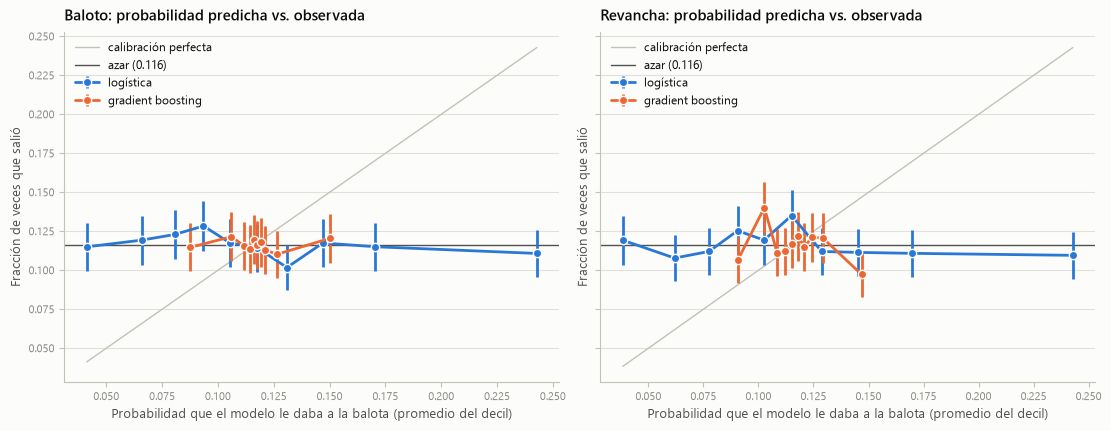

In [14]:
wf_gb = {j: walk_forward(MODELS["gradient_boosting"], data[j]) for j in JUEGOS}
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), sharey=True, layout="constrained")
for ax, j in zip(axes, JUEGOS):
    y = data[j].y_balls[wf_lg[j].test_idx]
    curvas = {
        "logistica": reliability_curve(wf_lg[j].probs.balls, y),
        "gradient_boosting": reliability_curve(wf_gb[j].probs.balls, y),
    }
    viz.reliability_panel(ax, curvas, P_BALL, f"{j.capitalize()}: probabilidad predicha vs. observada")
viz.save(fig, FIG / "calibracion.png")
plt.show()

In [15]:
sb, sr = (sig[j]["modelos"]["gradient_boosting"]["permutacion"]["metricas"]["skill_log_loss_balotas"] for j in JUEGOS)
display(Markdown(f"""## Conclusiones

- **No hay señal explotable.** En 384 sorteos de prueba por juego, ningún modelo supera al azar en aciertos ni al baseline constante en log-loss. Las pruebas de significancia coinciden: Monte Carlo sobre los resultados, percentil de las combinaciones ganadoras, permutación y historiales sintéticos con reentrenamiento (gradient boosting: percentil {sb['percentil']:.0f} en Baloto y {sr['percentil']:.0f} en Revancha frente a sus permutaciones).
- **El método sí ve señal cuando existe.** El control positivo muestra que el gradient boosting detecta una dinámica plantada en datos sintéticos; el resultado negativo con los datos reales, por lo tanto, es informativo.
- **Más complejidad, peor resultado.** Sobre un proceso aleatorio, el mejor pronóstico posible es el uniforme: cada parámetro extra solo añade varianza. La logística por balota lo ilustra con claridad.
- **Lo que queda por hacer lo hace el tiempo.** El registro en vivo guarda cada predicción antes del sorteo; los aciertos acumulados del modelo se compararán con los del azar a medida que lleguen nuevos resultados."""))

## Conclusiones

- **No hay señal explotable.** En 384 sorteos de prueba por juego, ningún modelo supera al azar en aciertos ni al baseline constante en log-loss. Las pruebas de significancia coinciden: Monte Carlo sobre los resultados, percentil de las combinaciones ganadoras, permutación y historiales sintéticos con reentrenamiento (gradient boosting: percentil 33 en Baloto y 6 en Revancha frente a sus permutaciones).
- **El método sí ve señal cuando existe.** El control positivo muestra que el gradient boosting detecta una dinámica plantada en datos sintéticos; el resultado negativo con los datos reales, por lo tanto, es informativo.
- **Más complejidad, peor resultado.** Sobre un proceso aleatorio, el mejor pronóstico posible es el uniforme: cada parámetro extra solo añade varianza. La logística por balota lo ilustra con claridad.
- **Lo que queda por hacer lo hace el tiempo.** El registro en vivo guarda cada predicción antes del sorteo; los aciertos acumulados del modelo se compararán con los del azar a medida que lleguen nuevos resultados.